Correct predictions % for the model per epoch is 81.89
Epoch 1 Summary: Train Loss: 0.823676, Test Loss: 0.512014

Intermediate Activations (First Training Batch):
relu_linear_model.0 output shape: torch.Size([64, 256])
relu_linear_model.1 output shape: torch.Size([64, 256])
relu_linear_model.2 output shape: torch.Size([64, 128])
relu_linear_model.3 output shape: torch.Size([64, 128])
relu_linear_model.4 output shape: torch.Size([64, 64])
relu_linear_model.5 output shape: torch.Size([64, 64])
relu_linear_model.6 output shape: torch.Size([64, 10])


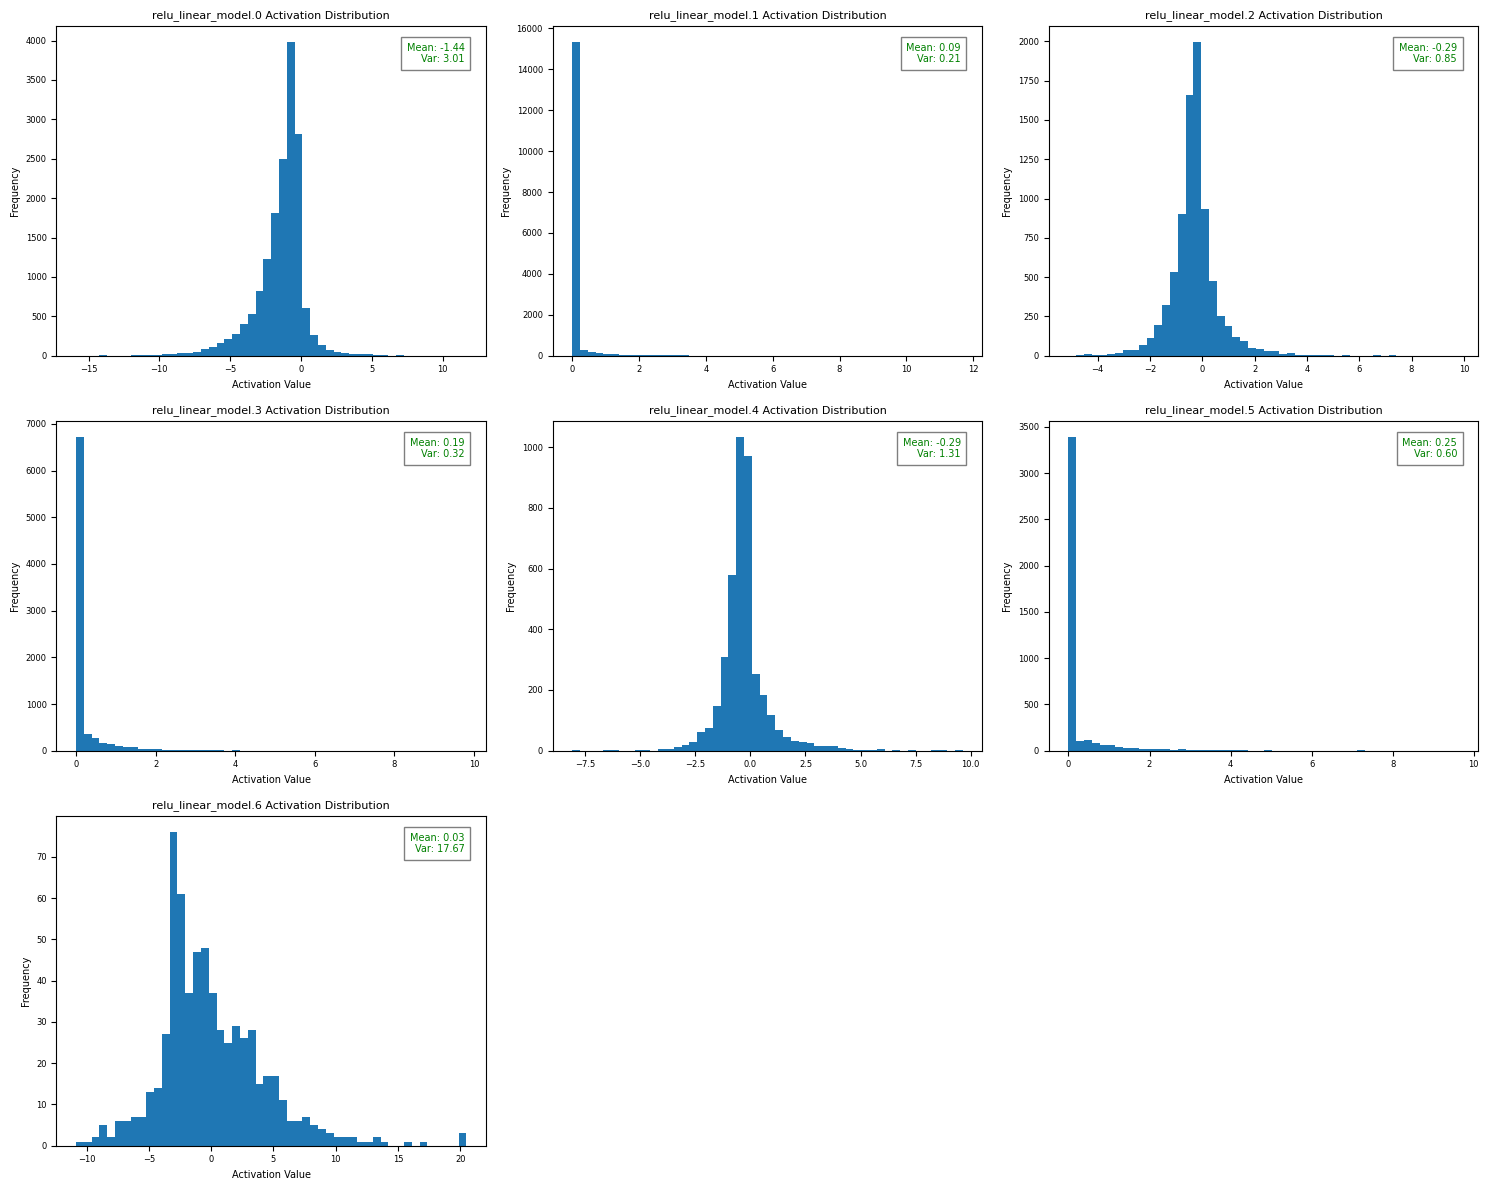

Correct predictions % for the model per epoch is 83.95
Epoch 2 Summary: Train Loss: 0.486169, Test Loss: 0.454767

Intermediate Activations (First Training Batch):
relu_linear_model.0 output shape: torch.Size([64, 256])
relu_linear_model.1 output shape: torch.Size([64, 256])
relu_linear_model.2 output shape: torch.Size([64, 128])
relu_linear_model.3 output shape: torch.Size([64, 128])
relu_linear_model.4 output shape: torch.Size([64, 64])
relu_linear_model.5 output shape: torch.Size([64, 64])
relu_linear_model.6 output shape: torch.Size([64, 10])


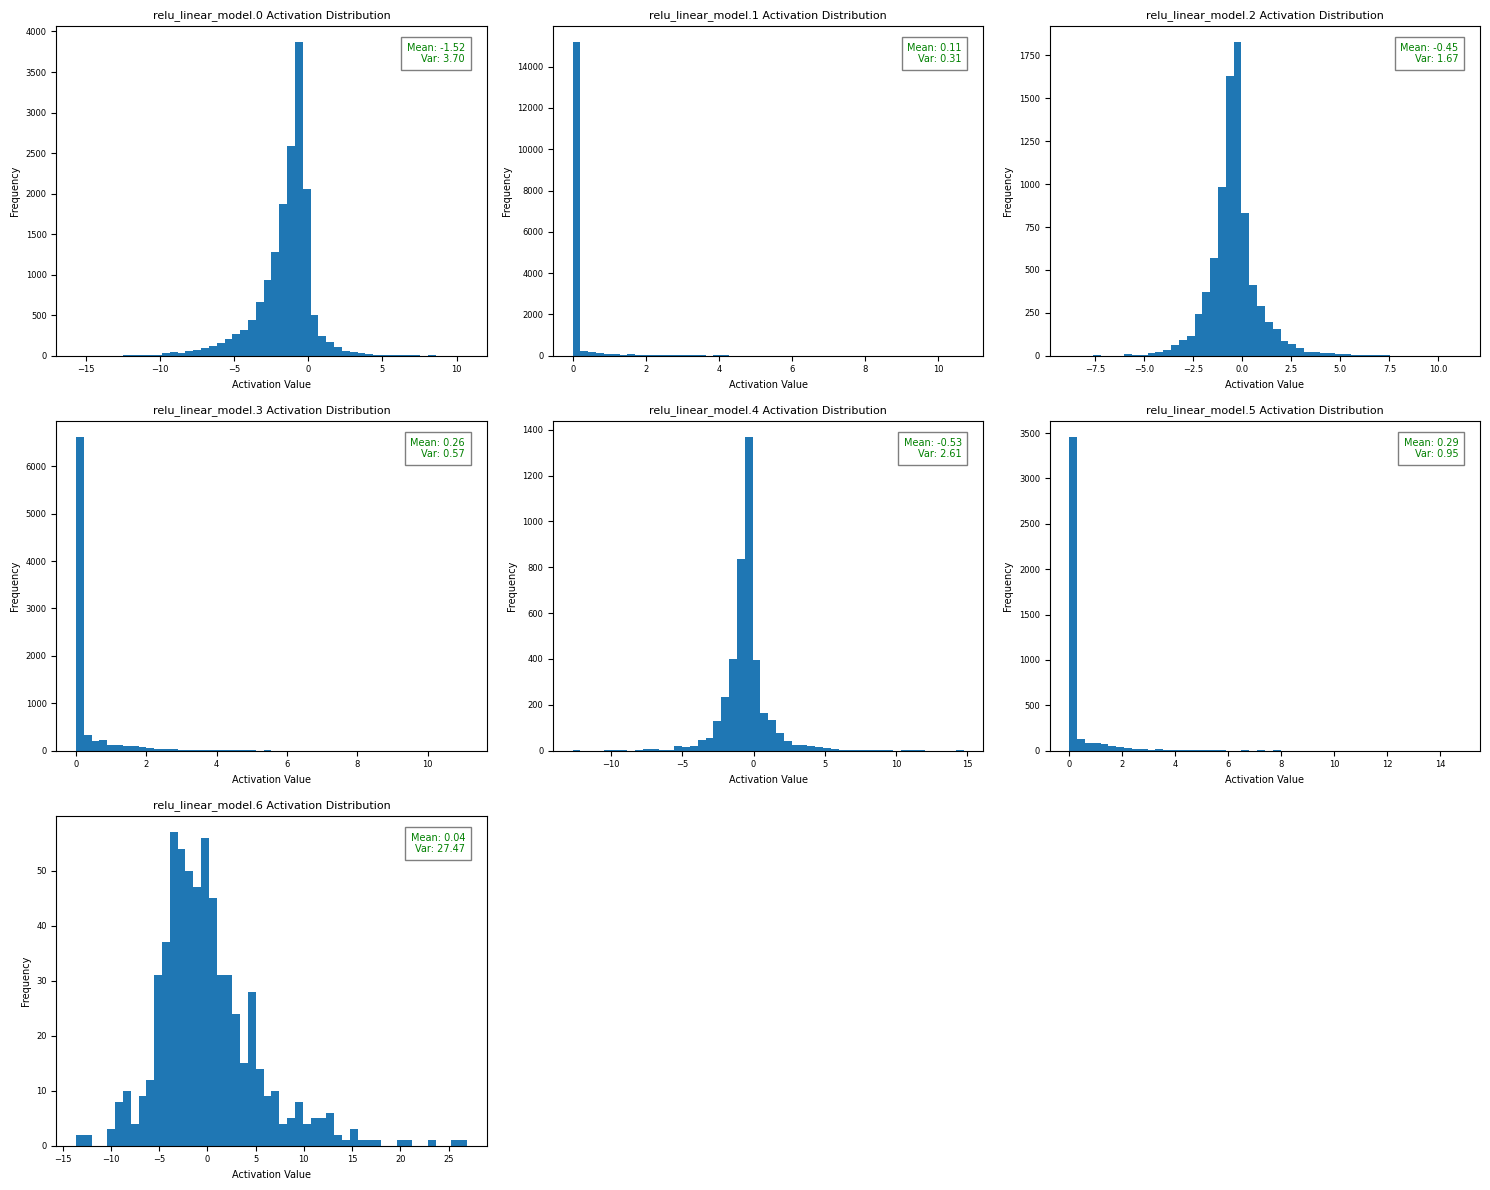

Correct predictions % for the model per epoch is 81.11
Epoch 3 Summary: Train Loss: 0.409363, Test Loss: 0.500813

Intermediate Activations (First Training Batch):
relu_linear_model.0 output shape: torch.Size([64, 256])
relu_linear_model.1 output shape: torch.Size([64, 256])
relu_linear_model.2 output shape: torch.Size([64, 128])
relu_linear_model.3 output shape: torch.Size([64, 128])
relu_linear_model.4 output shape: torch.Size([64, 64])
relu_linear_model.5 output shape: torch.Size([64, 64])
relu_linear_model.6 output shape: torch.Size([64, 10])


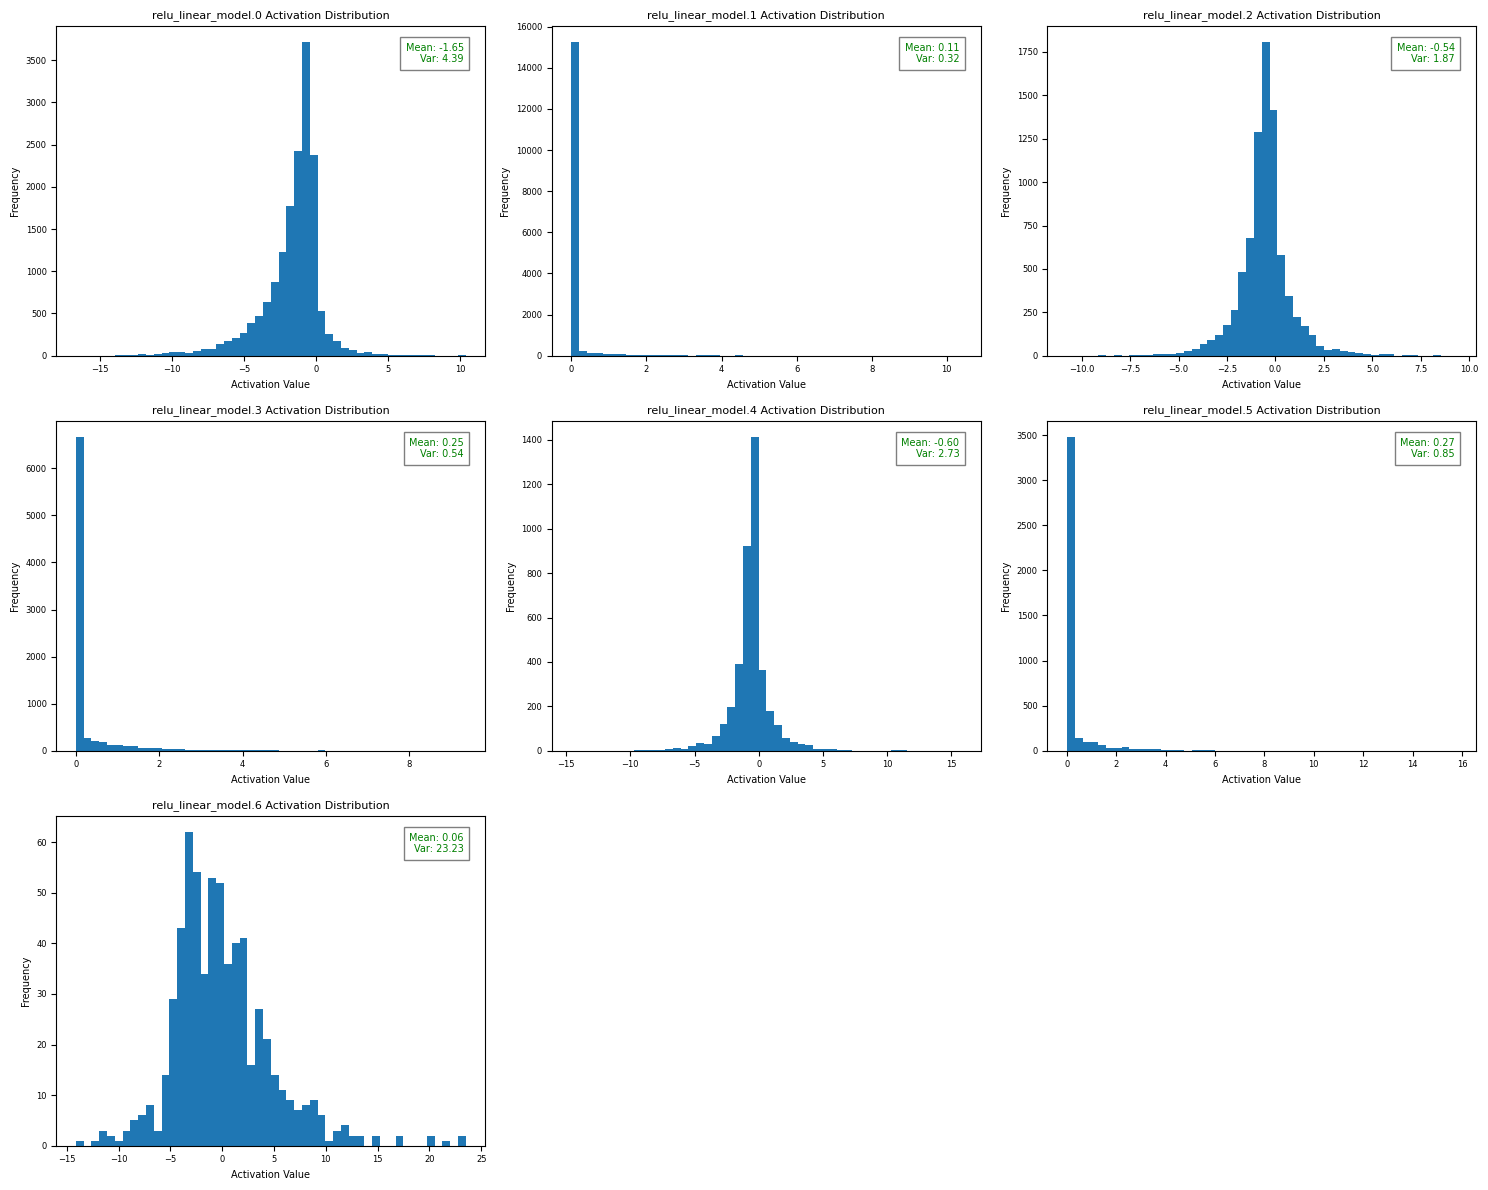

Correct predictions % for the model per epoch is 86.03
Epoch 4 Summary: Train Loss: 0.374855, Test Loss: 0.391657

Intermediate Activations (First Training Batch):
relu_linear_model.0 output shape: torch.Size([64, 256])
relu_linear_model.1 output shape: torch.Size([64, 256])
relu_linear_model.2 output shape: torch.Size([64, 128])
relu_linear_model.3 output shape: torch.Size([64, 128])
relu_linear_model.4 output shape: torch.Size([64, 64])
relu_linear_model.5 output shape: torch.Size([64, 64])
relu_linear_model.6 output shape: torch.Size([64, 10])


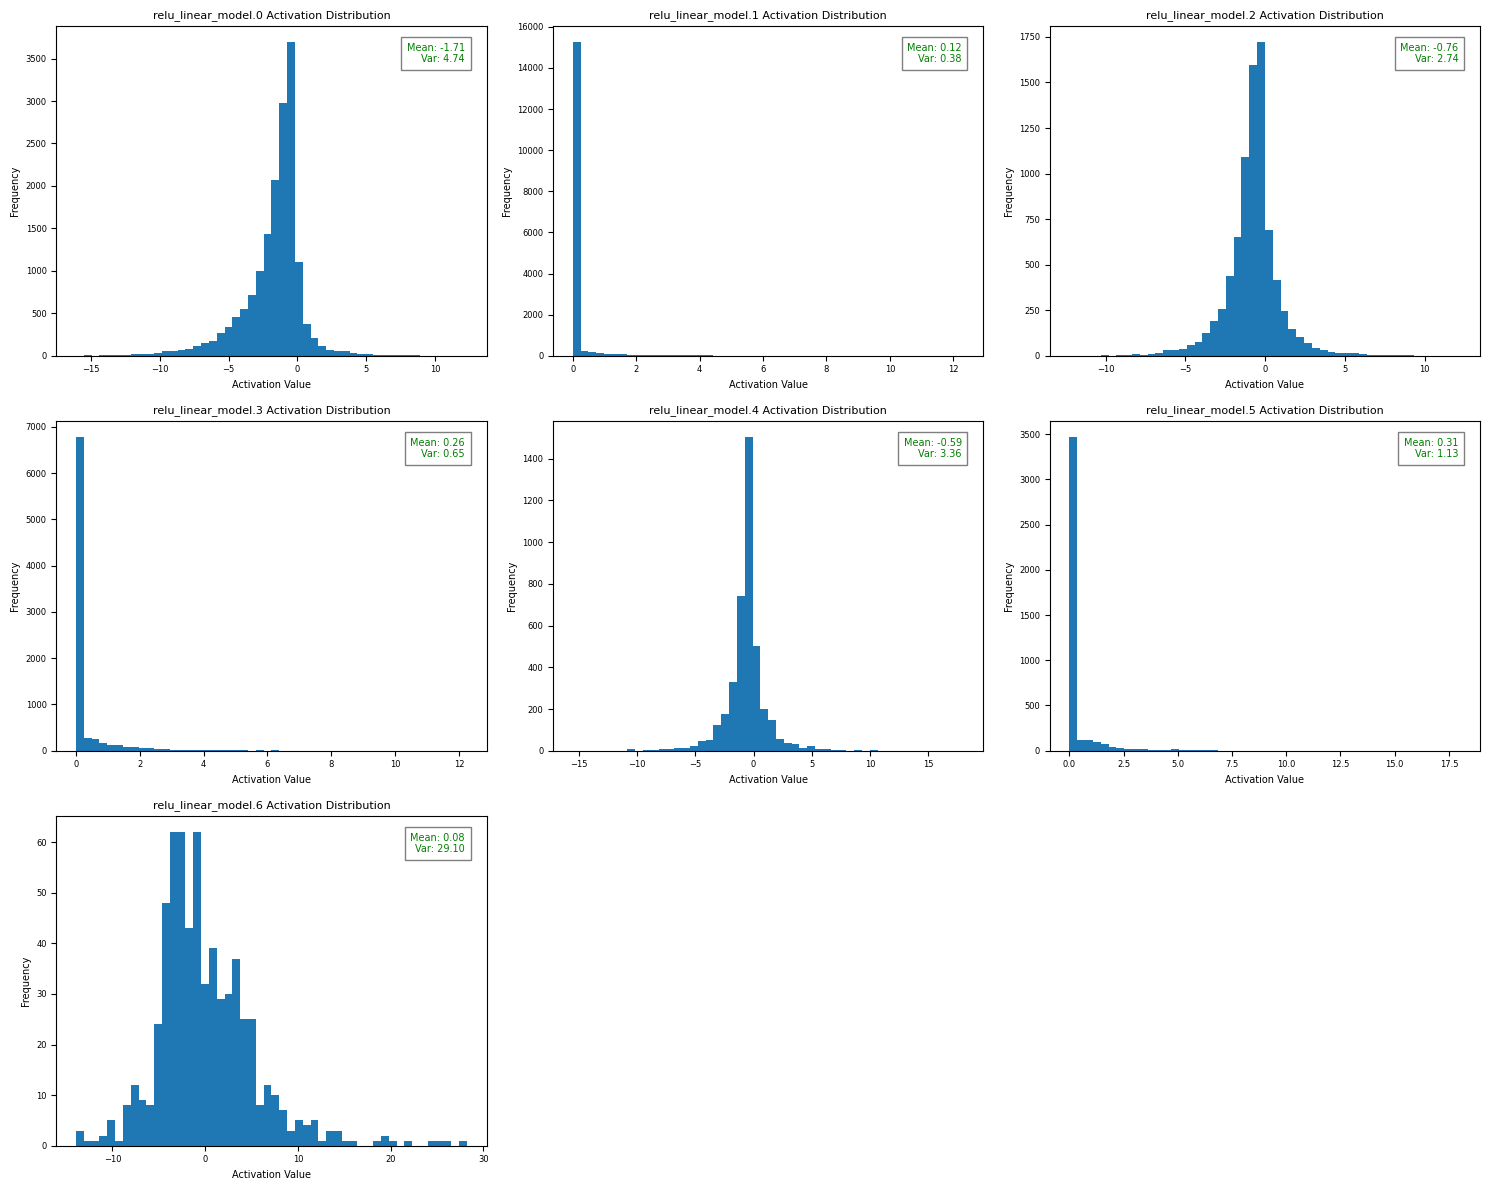

Correct predictions % for the model per epoch is 84.97
Epoch 5 Summary: Train Loss: 0.353613, Test Loss: 0.423077

Intermediate Activations (First Training Batch):
relu_linear_model.0 output shape: torch.Size([64, 256])
relu_linear_model.1 output shape: torch.Size([64, 256])
relu_linear_model.2 output shape: torch.Size([64, 128])
relu_linear_model.3 output shape: torch.Size([64, 128])
relu_linear_model.4 output shape: torch.Size([64, 64])
relu_linear_model.5 output shape: torch.Size([64, 64])
relu_linear_model.6 output shape: torch.Size([64, 10])


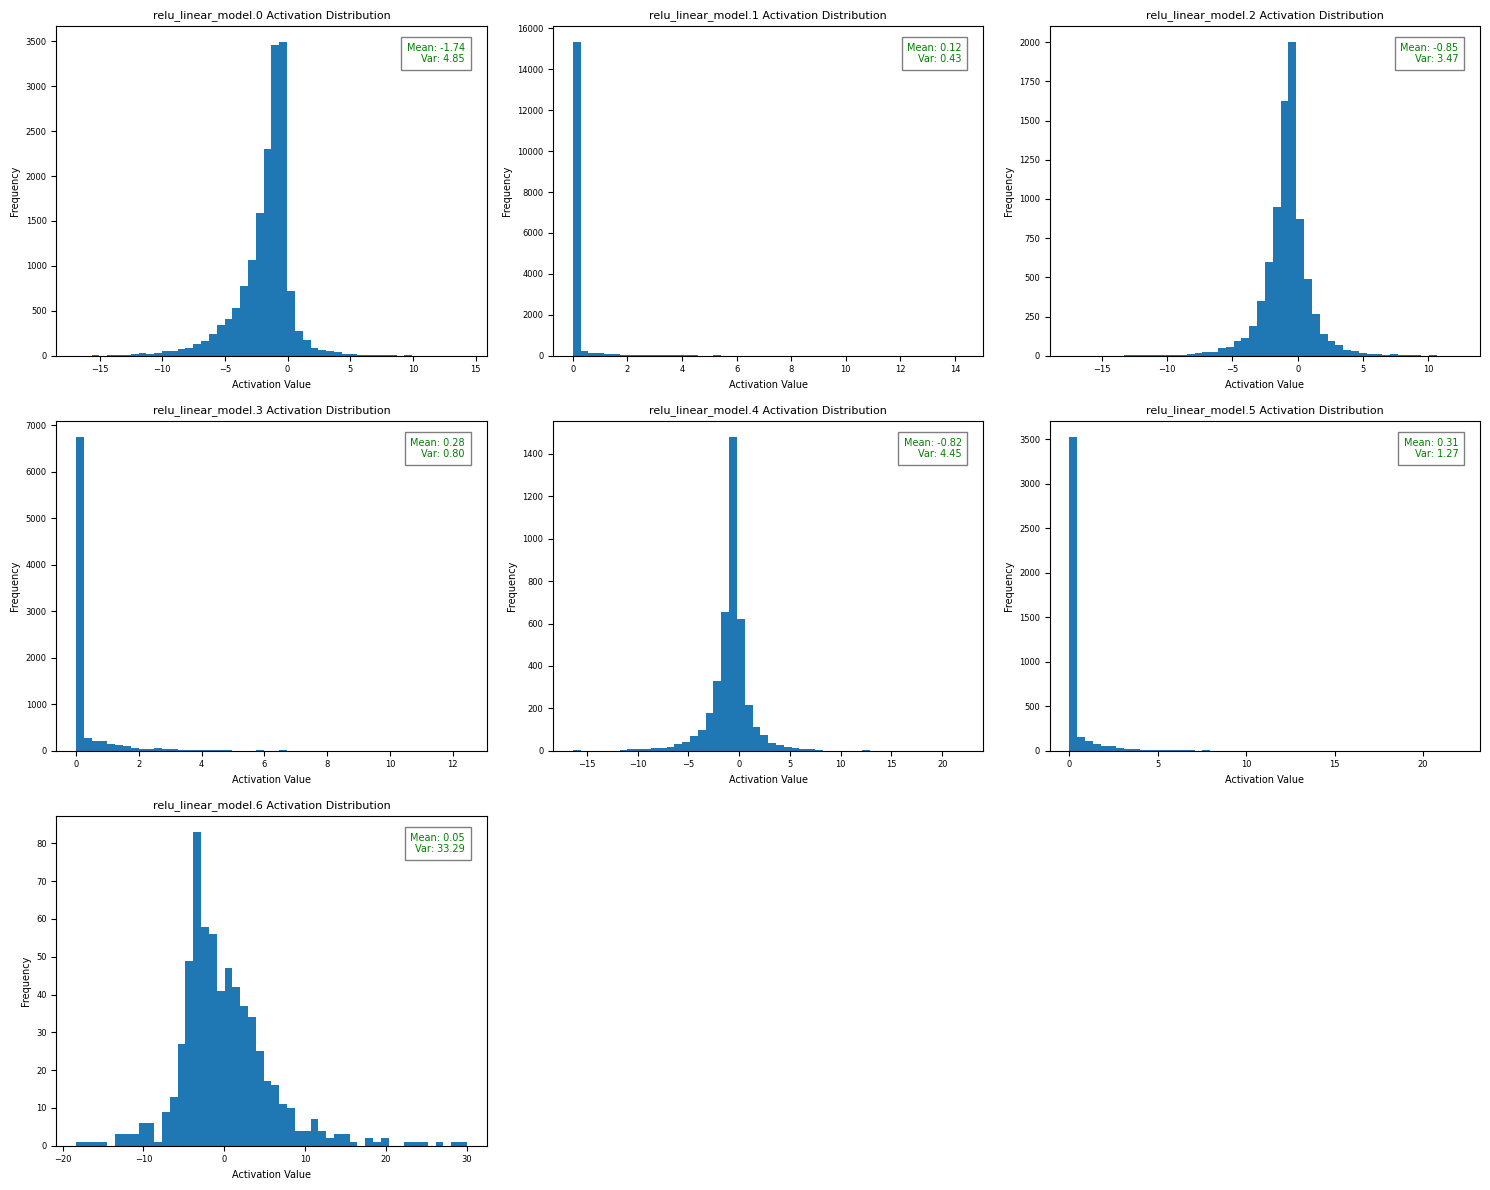

In [6]:
'''
Q1.

Explore what causes slow training in multilayer perceptron neural networks even in
the absence of vanishing gradients
To observe, visualize, and reason about unexpected change of input-distribution in hidden
layers during neural network training. Use pytorch’s module and pytorch’s forward hooks for
implementation

'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import nn


epochs = 5
learning_rate = 0.5 # try 0.25. 0.1, 0.05
b_size = 64
neurons_per_layer = [784, 256, 128, 64, 10]
total_layers = len(neurons_per_layer)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything()


train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

# Download and load test data
test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

train_data_loader = DataLoader(train_dataset,
                                          batch_size= b_size,
                                          shuffle= True,
                                          num_workers= 1)

test_data_loader = DataLoader(test_dataset,
                                          batch_size= b_size,
                                          shuffle= True,
                                          num_workers= 1)

loss_fn = nn.CrossEntropyLoss()


class NeuralNetwork(nn.Module):

  def __init__(self, total_layers:int, neurons_per_layer:list):
    super().__init__()
    self.total_layers = total_layers
    self.neurons_per_layer = neurons_per_layer # neurons_per_layer = [784, 256, 128, 64, 10]
    self.relu_linear_model = nn.Sequential(
                                  nn.Linear(neurons_per_layer[0], neurons_per_layer[1]), # 784 * 256
                                  nn.ReLU(),
                                  nn.Linear(neurons_per_layer[1], neurons_per_layer[2]), # 256 * 128
                                  nn.ReLU(),
                                  nn.Linear(neurons_per_layer[2], neurons_per_layer[3]), # 128 * 64
                                  nn.ReLU(),
                                  nn.Linear(neurons_per_layer[3], neurons_per_layer[4]), # 64 * 10
                              )
  def forward(self, X):
    flatten_input = nn.Flatten()
    batch_labels = self.relu_linear_model(flatten_input(X))
    return batch_labels


def train_per_epoch(dataloader, model, loss_fn, optimizer):
  total_data_size = len(dataloader.dataset)
  model.train()
  running_loss = 0.0
  for batch_index, (X, y) in enumerate(dataloader):
    batch_labels = model.forward(X)
    loss = loss_fn(batch_labels, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    running_loss += loss.item()
    epoch_loss = running_loss / len(dataloader)
  return epoch_loss


def test_per_epoch(dataloader, model, loss_fn):  # for 10K records
  model.eval()
  test_dataset_size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss = 0
  correct = 0.0
  with torch.no_grad():
    for X, y in dataloader:
      batch_labels = model(X)
      test_loss += loss_fn(batch_labels, y).item()
      correct += (batch_labels.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= test_dataset_size
  correct = correct * 100
  print(f'Correct predictions % for the model per epoch is {correct}')
  return test_loss



model = NeuralNetwork(total_layers, neurons_per_layer) #Initialize NN.
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #Initialize Optimizer
activations = {}

def get_activation(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

#register forward hooks
for i, module in enumerate(model.relu_linear_model):
    module.register_forward_hook(get_activation(f"relu_linear_model.{i}"))

fixed_X, fixed_y = next(iter(train_data_loader))

activation_mean_per_epoch = []
activation_variance_per_epoch = []

# Initialize lists for weight and bias statistics
weight_mean_per_epoch = []
weight_variance_per_epoch = []
bias_mean_per_epoch = []
bias_variance_per_epoch = []

for t in range(epochs):
    train_loss = train_per_epoch(train_data_loader, model, loss_fn, optimizer)
    test_loss = test_per_epoch(test_data_loader, model, loss_fn)
    print(f"Epoch {t+1} Summary: Train Loss: {train_loss:>8f}, Test Loss: {test_loss:>8f}\n")
    print("Intermediate Activations (First Training Batch):")
    with torch.no_grad():
        pred = model(fixed_X)

    num_layers = len(activations)
    rows = int(np.ceil(np.sqrt(num_layers)))
    cols = int(np.ceil(num_layers / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()
    activation_means_per_layer = []
    activation_variance_per_layer = []
    for i, (layer_name, activation_tensor) in enumerate(activations.items()):
      activation_mean = activation_tensor.mean().item()
      activation_var = activation_tensor.var().item()
      activation_means_per_layer.append(activation_mean)
      activation_variance_per_layer.append(activation_var)
      print(f"{layer_name} output shape: {activation_tensor.shape}")
      ax = axes[i]
      ax.hist(activation_tensor.numpy().flatten(), bins=50)
      ax.set_title(f"{layer_name} Activation Distribution", fontsize=8)
      ax.set_xlabel("Activation Value", fontsize=7)
      ax.set_ylabel("Frequency", fontsize=7)
      ax.tick_params(axis='both', which='major', labelsize=6)
      ax.text(0.95, 0.95, f'Mean: {activation_mean:.2f}\nVar: {activation_var:.2f}',
              verticalalignment='top', horizontalalignment='right',
              transform=ax.transAxes, color='green', fontsize=7, bbox=dict(facecolor='white', alpha=0.5))
    activation_mean_per_epoch.append(activation_means_per_layer)
    activation_variance_per_epoch.append(activation_variance_per_layer)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()




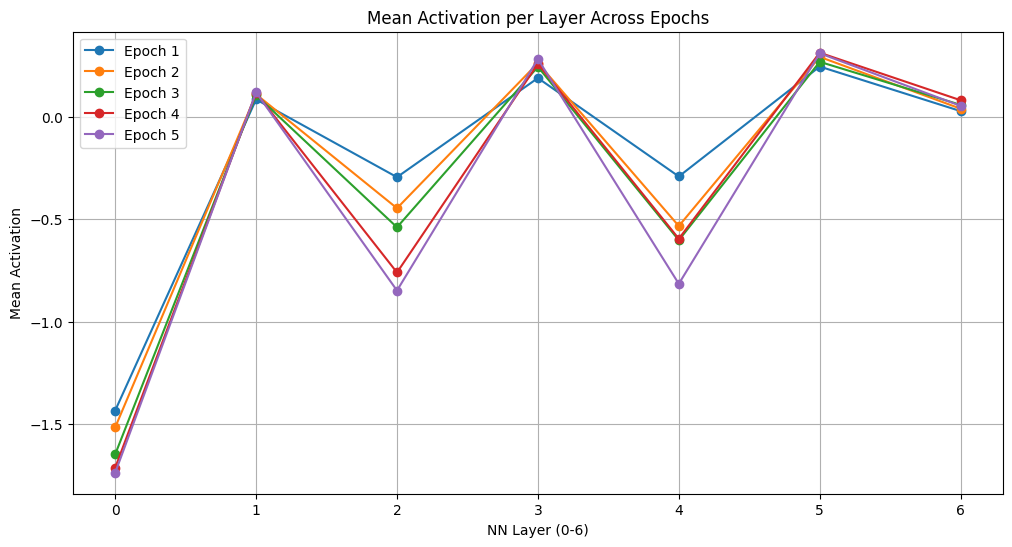

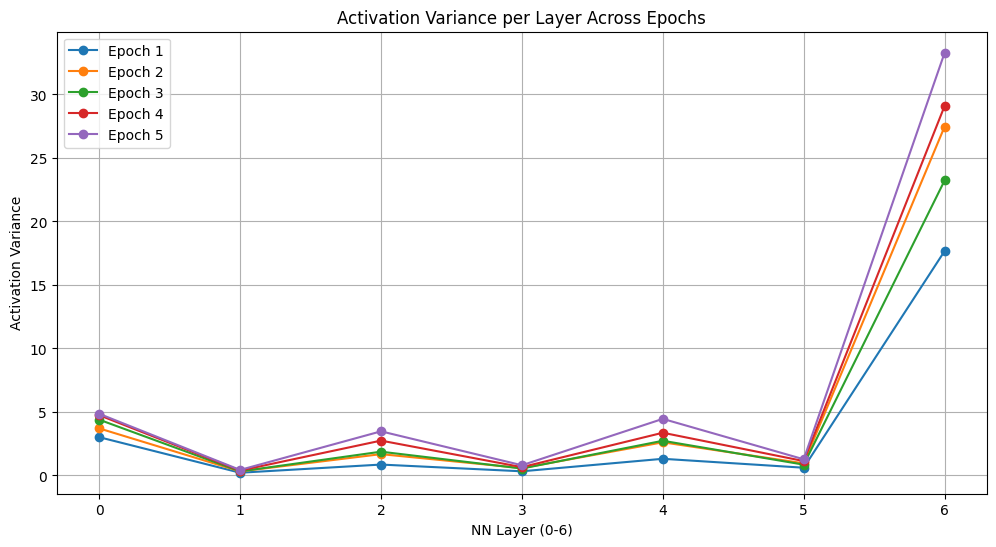

In [7]:
plt.figure(figsize=(12, 6))
for i, means in enumerate(activation_mean_per_epoch):
    plt.plot(means, marker='o', label=f'Epoch {i+1}')
plt.xlabel("NN Layer (0-6)")
plt.ylabel("Mean Activation")
plt.title("Mean Activation per Layer Across Epochs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
for i, variances in enumerate(activation_variance_per_epoch):
    plt.plot(variances, marker='o', label=f'Epoch {i+1}') # Removed fixed color='red'
plt.xlabel("NN Layer (0-6)")
plt.ylabel("Activation Variance")
plt.title("Activation Variance per Layer Across Epochs")
plt.grid(True)
plt.legend()
plt.show()

torch.Size([32, 25])

In [ ]:
 '''
    Observation:
    Regarding the Batch Distribution:
    From the NN used, The Fixed batch distribution is varying from one layer to another layer (btw Linear activations and the RELU activations)
    The mean and variance btw two RELU layers and two Linear layers are also different and has a significant shift.
    The mean and variance across the layers from the second plot is also not uniform signifying the impact of the shift.
    '''

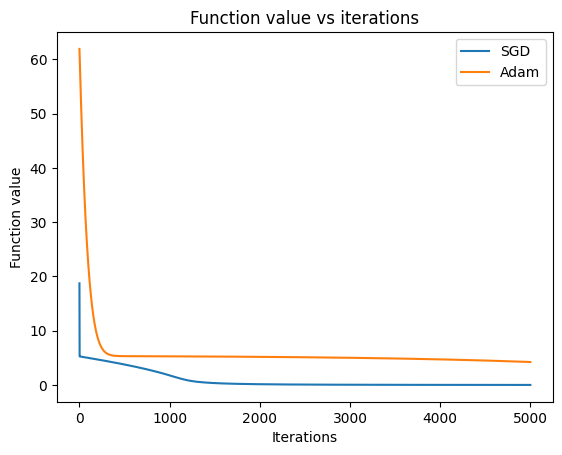

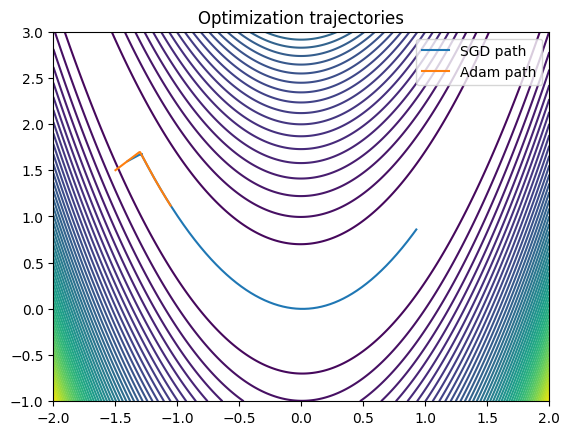

Learning Rate Comparison

LR: 0.1
SGD final loss: 37062.5
Adam final loss: 2.0831658572272996e-08

LR: 0.01
SGD final loss: 62.5
Adam final loss: 4.2407925515068815e-05

LR: 0.001
SGD final loss: 0.005322114496165698
Adam final loss: 4.22353038778994

LR: 0.0001
SGD final loss: 3.7153014307059675
Adam final loss: 5.28820428504049



In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    return (1-x)**2 + 100*(y-x**2)**2

def grad(x,y):

    dx = -2*(1-x) - 400*x*(y-x**2)
    dy = 200*(y-x**2)

    return np.array([dx,dy],dtype=np.float64)

def sgd(lr,iterations,init):

    theta = np.array(init,dtype=np.float64)

    trajectory=[]
    values=[]

    for i in range(iterations):
        g = grad(theta[0],theta[1])
        g = np.clip(g,-100,100)
        theta = theta - lr*g

        if np.any(np.isnan(theta)) or np.any(np.isinf(theta)):
            break

        trajectory.append(theta.copy())
        values.append(f(theta[0],theta[1]))

    return np.array(trajectory),np.array(values)


def adam(lr,iterations,init):

    theta=np.array(init,dtype=np.float64)

    m=np.zeros(2)
    v=np.zeros(2)

    beta1=0.9
    beta2=0.999
    eps=1e-8

    trajectory=[]
    values=[]

    for t in range(1,iterations+1):

        g=grad(theta[0],theta[1])

        m = beta1*m + (1-beta1)*g
        v = beta2*v + (1-beta2)*(g*g)

        m_hat = m/(1-beta1**t)
        v_hat = v/(1-beta2**t)

        theta = theta - lr*m_hat/(np.sqrt(v_hat)+eps)

        if np.any(np.isnan(theta)) or np.any(np.isinf(theta)):
            break

        trajectory.append(theta.copy())
        values.append(f(theta[0],theta[1]))

    return np.array(trajectory),np.array(values)

iterations=5000
init=[-1.5,1.5]
lr=1e-3

sgd_traj,sgd_vals=sgd(lr,iterations,init)
adam_traj,adam_vals=adam(lr,iterations,init)

plt.figure()

plt.plot(sgd_vals,label="SGD")
plt.plot(adam_vals,label="Adam")

plt.xlabel("Iterations")
plt.ylabel("Function value")

plt.title("Function value vs iterations")

plt.legend()

plt.show()


x=np.linspace(-2,2,400)
y=np.linspace(-1,3,400)

X,Y=np.meshgrid(x,y)

Z=(1-X)**2+100*(Y-X**2)**2

plt.figure()

plt.contour(X,Y,Z,levels=50)

plt.plot(sgd_traj[:,0],sgd_traj[:,1],label="SGD path")
plt.plot(adam_traj[:,0],adam_traj[:,1],label="Adam path")

plt.legend()

plt.title("Optimization trajectories")

plt.show()


lrs=[1e-1,1e-2,1e-3,1e-4]

print("Learning Rate Comparison\n")
for lr in lrs:

    _,sgd_vals=sgd(lr,iterations,init)
    _,adam_vals=adam(lr,iterations,init)

    sgd_final = sgd_vals[-1] if len(sgd_vals)>0 else "Diverged"
    adam_final = adam_vals[-1] if len(adam_vals)>0 else "Diverged"

    print("LR:",lr)
    print("SGD final loss:",sgd_final)
    print("Adam final loss:",adam_final)
    print()

RMSProp final w: [2.22617723 1.79176897]
RMSProp final loss: 1611.6600391641527
Adam final w: [3.83751505e+00 6.68345548e-05]
Adam final loss: 4.157795028000253


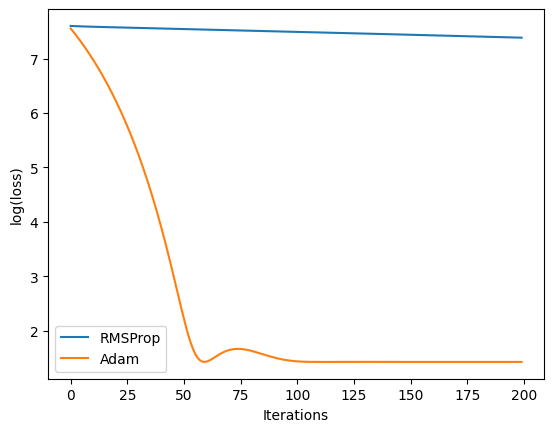

In [10]:
'''
Consider the non-convex function:
f(w1, w2) = 1/2(w_1^2 + 1000w_2^2)+ 5 sin(w_1)
(a) Implement RMSProp and Adam from scratch.

'''
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    w1,w2 = w
    return 0.5*(w1**2 + 1000*w2**2) + 5*np.sin(w1)

def grad(w):

    w1,w2 = w

    g1 = w1 + 5*np.cos(w1)
    g2 = 1000*w2

    return np.array([g1,g2])

def RMSProp(w_init, lr=0.001, beta=0.9, eps=1e-8, iters=200):

    w = w_init.copy()
    v = np.zeros(2)

    losses = []

    for i in range(iters):

        g = grad(w)

        v = beta*v + (1-beta)*(g**2)

        w = w - lr * g/(np.sqrt(v)+eps)

        losses.append(f(w))

    return w, losses

def Adam(w_init, lr=0.05,
         beta1=0.9,
         beta2=0.999,
         eps=1e-8,
         iters=200):

    w = w_init.copy()

    m = np.zeros(2)
    v = np.zeros(2)

    losses = []

    for t in range(1,iters+1):

        g = grad(w)

        m = beta1*m + (1-beta1)*g
        v = beta2*v + (1-beta2)*(g**2)

        mhat = m/(1-beta1**t)
        vhat = v/(1-beta2**t)

        w = w - lr*mhat/(np.sqrt(vhat)+eps)

        losses.append(f(w))

    return w, losses


w0 = np.array([2.0,2.0])

w_rms , loss_rms = RMSProp(w0)
w_adam, loss_adam = Adam(w0)

print("RMSProp final w:",w_rms)
print("RMSProp final loss:",loss_rms[-1])

print("Adam final w:",w_adam)
print("Adam final loss:",loss_adam[-1])

plt.plot(np.log(loss_rms),label="RMSProp")
plt.plot(np.log(loss_adam),label="Adam")

plt.xlabel("Iterations")
plt.ylabel("log(loss)")
plt.legend()

plt.show()

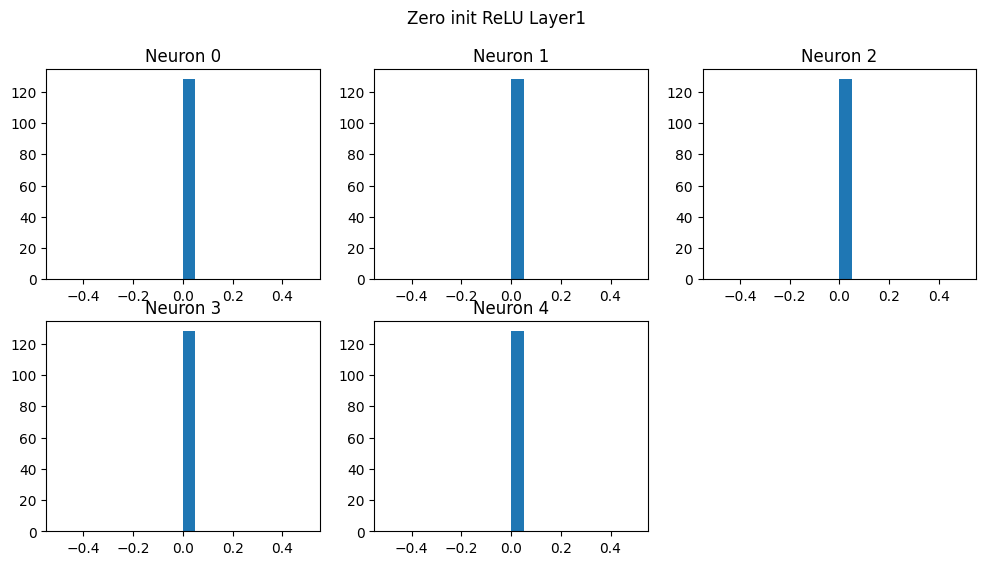

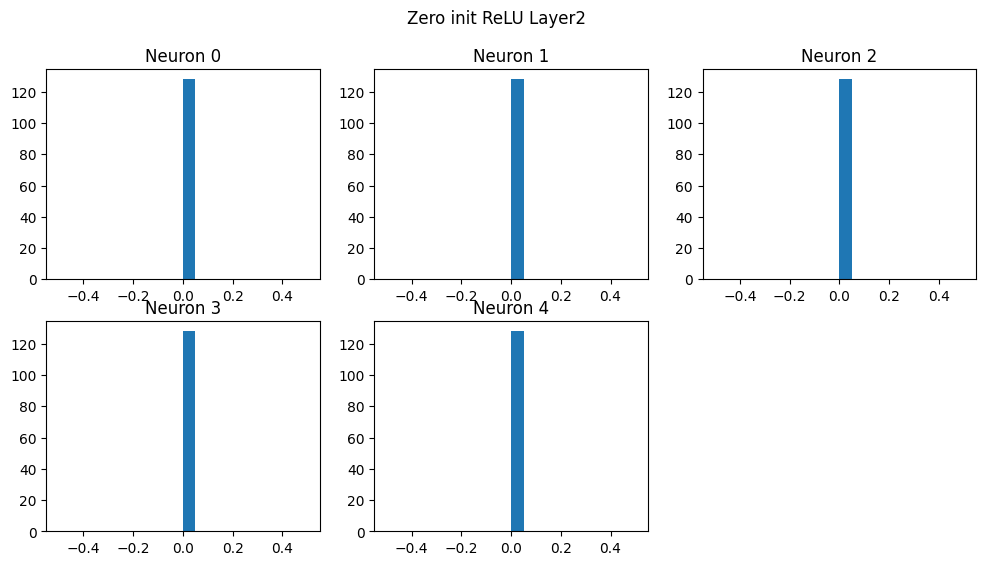

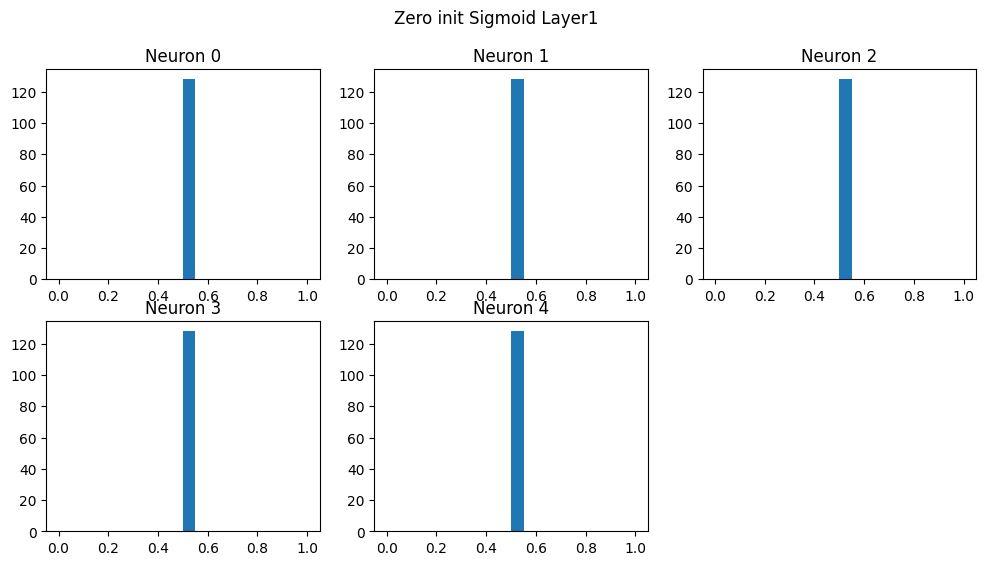

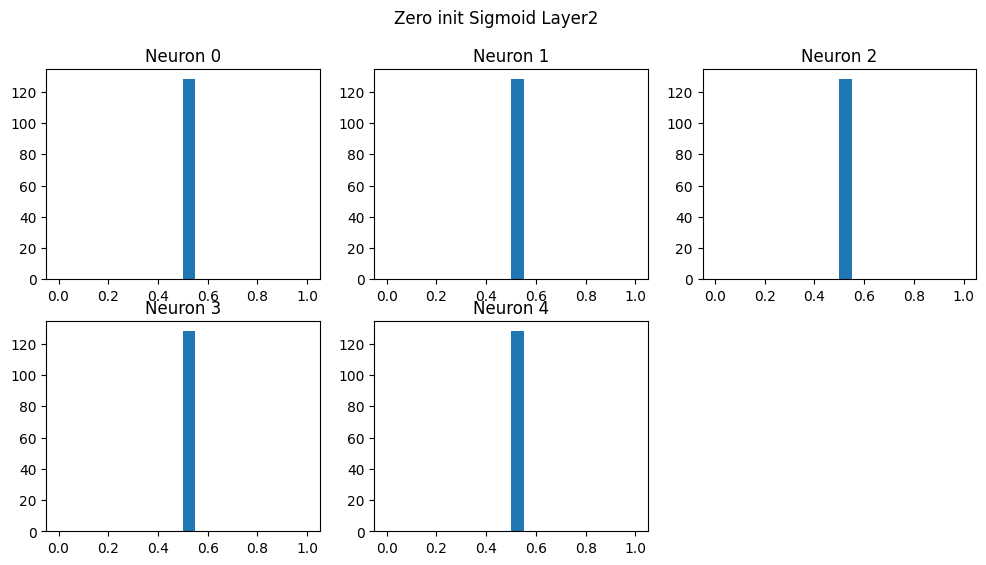

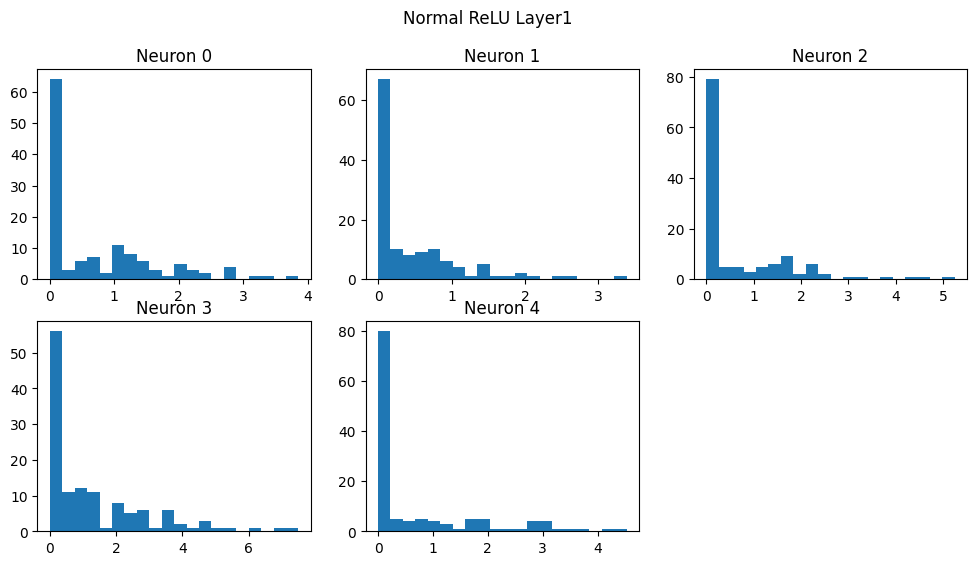

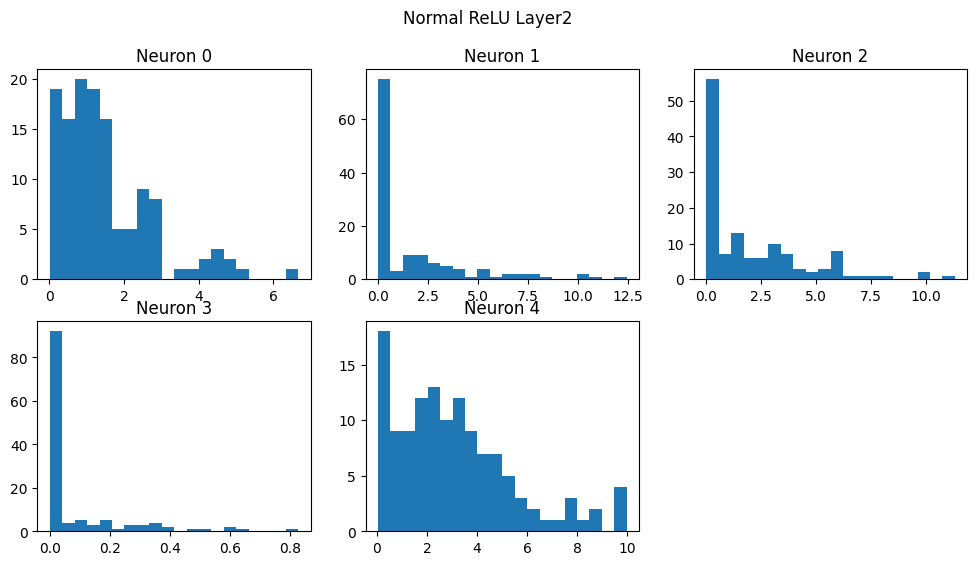

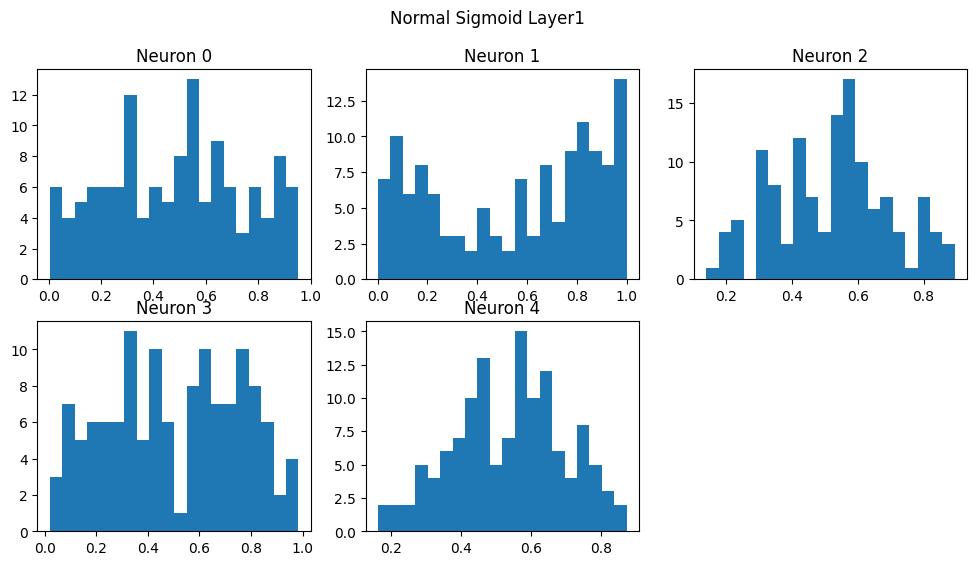

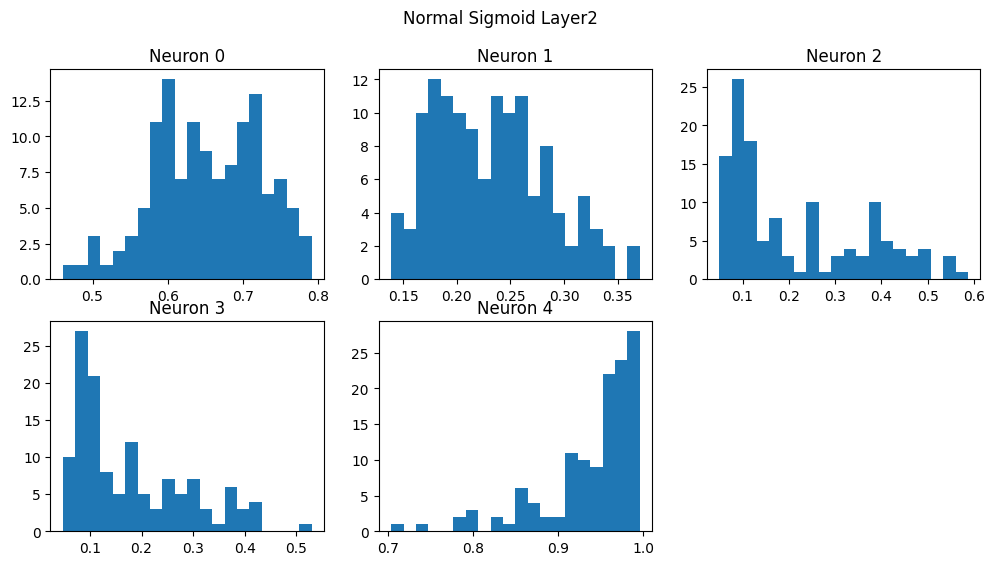

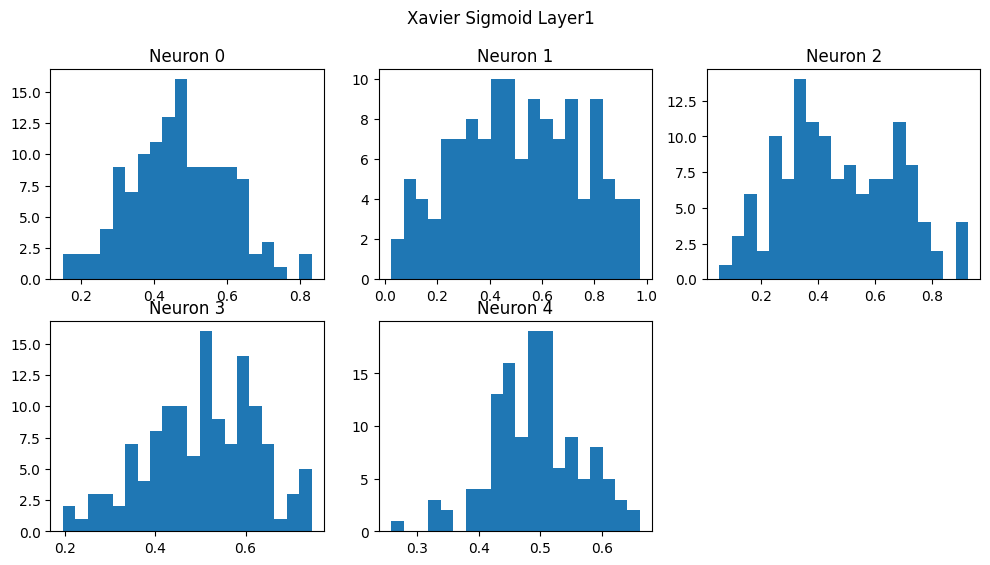

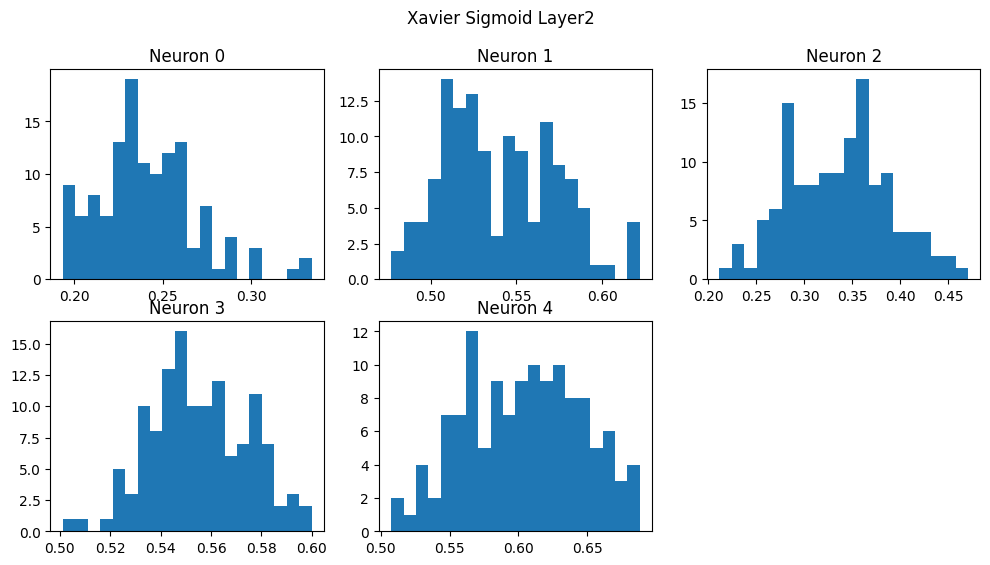

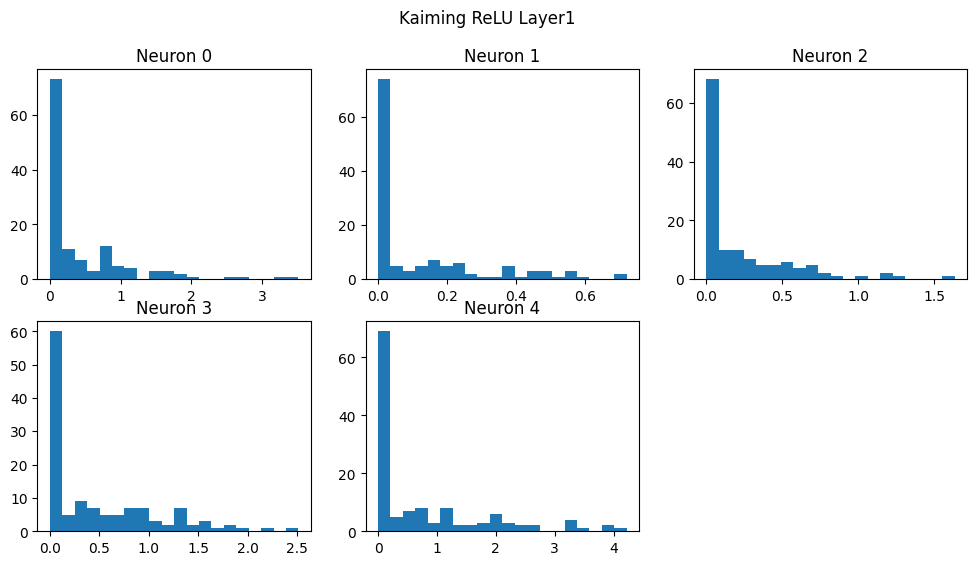

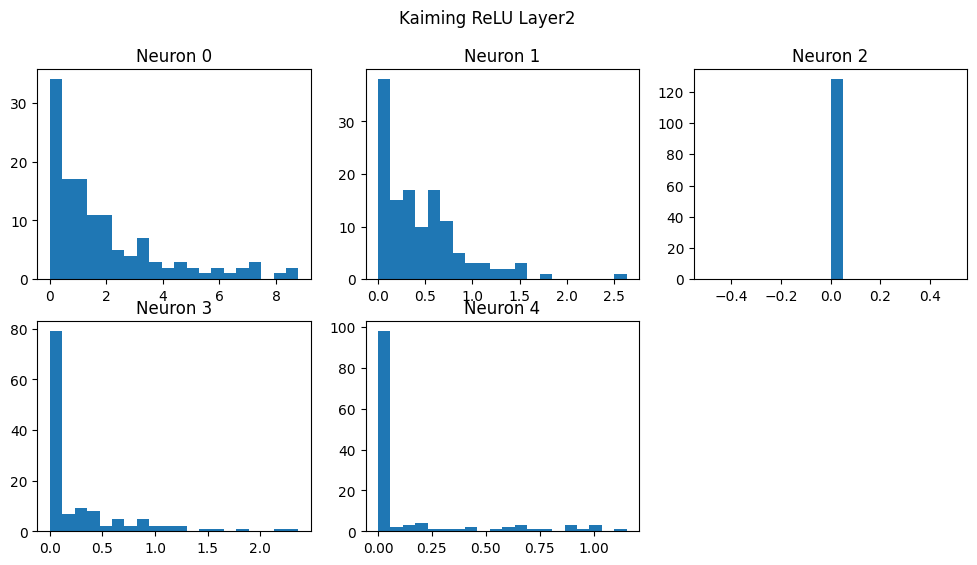

In [11]:
'''
8. Empirically validate the need for specific weight initialization strategies.
Task: Build a 2-layer Multilayer Perceptron (MLP) without using high-level framework layers (e.g., use NumPy matrix multiplications).
'''

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def relu(x):
    return np.maximum(0,x)

def sigmoid(x):

    return 1/(1+np.exp(-x))

def zero_init(nin,nout):

    return np.zeros((nin,nout))

def normal_init(nin,nout):

    return np.random.randn(nin,nout)

def xavier_init(nin,nout):

    std = np.sqrt(2/(nin+nout))

    return np.random.randn(nin,nout)*std

def kaiming_init(nin,nout):

    std = np.sqrt(2/nin)

    return np.random.randn(nin,nout)*std

def forward(X,W1,W2,W3,activation):

    Z1 = X @ W1
    A1 = activation(Z1)

    Z2 = A1 @ W2
    A2 = activation(Z2)

    Z3 = A2 @ W3

    return A1,A2,Z3

X = np.random.randn(128,3)

def build_network(init_type,activation):

    nin=3
    nh=5
    nout=5

    if init_type=="zero":

        W1=zero_init(nin,nh)
        W2=zero_init(nh,nh)
        W3=zero_init(nh,nout)

    elif init_type=="normal":

        W1=normal_init(nin,nh)
        W2=normal_init(nh,nh)
        W3=normal_init(nh,nout)

    elif init_type=="xavier":

        W1=xavier_init(nin,nh)
        W2=xavier_init(nh,nh)
        W3=xavier_init(nh,nout)

    elif init_type=="kaiming":

        W1=kaiming_init(nin,nh)
        W2=kaiming_init(nh,nh)
        W3=kaiming_init(nh,nout)

    A1,A2,out = forward(X,W1,W2,W3,activation)

    return A1,A2

def plot_layer(layer,name):

    plt.figure(figsize=(12,6))

    for i in range(5):

        plt.subplot(2,3,i+1)

        plt.hist(layer[:,i],bins=20)

        plt.title(f"Neuron {i}")

    plt.suptitle(name)

    plt.show()

# Zero + ReLU
A1,A2 = build_network("zero",relu)

plot_layer(A1,"Zero init ReLU Layer1")
plot_layer(A2,"Zero init ReLU Layer2")

# Zero + Sigmoid
A1,A2 = build_network("zero",sigmoid)

plot_layer(A1,"Zero init Sigmoid Layer1")
plot_layer(A2,"Zero init Sigmoid Layer2")

# Normal + ReLU
A1,A2 = build_network("normal",relu)

plot_layer(A1,"Normal ReLU Layer1")
plot_layer(A2,"Normal ReLU Layer2")

# Normal + Sigmoid
A1,A2 = build_network("normal",sigmoid)

plot_layer(A1,"Normal Sigmoid Layer1")
plot_layer(A2,"Normal Sigmoid Layer2")

# Xavier Sigmoid
A1,A2 = build_network("xavier",sigmoid)

plot_layer(A1,"Xavier Sigmoid Layer1")
plot_layer(A2,"Xavier Sigmoid Layer2")

# Kaiming ReLU
A1,A2 = build_network("kaiming",relu)

plot_layer(A1,"Kaiming ReLU Layer1")
plot_layer(A2,"Kaiming ReLU Layer2")

In [ ]:
'''
Observation:
Zero initialization causes all neurons to produce identical outputs resulting
in zero variance and preventing symmetry breaking, making learning impossible.

Standard normal initialization causes activation variance to grow across
layers due to multiplication with large weight variance, leading to exploding activations in ReLU networks and saturation in sigmoid networks.

Xavier initialization maintains stable activation variance across layers
for sigmoid activations by balancing forward and backward signal propagation,
preventing vanishing gradients.

Kaiming initialization compensates for variance reduction caused by ReLU
nonlinearity by scaling weights according to input size,
preserving activation magnitude across layers and enabling stable gradient flow.

This experiment empirically validates that proper initialization
prevents vanishing and exploding activations and is necessary
for stable deep network training
'''

Iter: 0 w: 1.4683772236483161 loss: 2.0
Iter: 1 w: 1.4457880251092234 loss: 1.8755088945616418
Iter: 2 w: 1.4270530982533376 loss: 1.7890299768800102
Iter: 3 w: 1.4105434560590302 loss: 1.7188548939622248
Iter: 4 w: 1.3955067104131256 loss: 1.658178770743846
Iter: 5 w: 1.3815248273777012 loss: 1.6038645367898752
Iter: 6 w: 1.3683382985710137 loss: 1.554172042566572
Iter: 7 w: 1.3557735826894246 loss: 1.508022801530406
Iter: 8 w: 1.3437082569466443 loss: 1.464696849658187
Iter: 9 w: 1.332052415846295 loss: 1.4236872456798895
Iter: 10 w: 1.3207379348046013 loss: 1.3846224454313116
Iter: 11 w: 1.309711887180951 loss: 1.347221515254644
Iter: 12 w: 1.2989323085716282 loss: 1.3112666804842743
Iter: 13 w: 1.2883653618355475 loss: 1.2765856673591827
Iter: 14 w: 1.2779833762429909 loss: 1.2430398874841875
Iter: 15 w: 1.2677634529355553 loss: 1.210516267420886
Iter: 16 w: 1.25768644915051 loss: 1.178921439327053
Iter: 17 w: 1.2477362228196014 loss: 1.1481775104526166
Iter: 18 w: 1.23789906048640

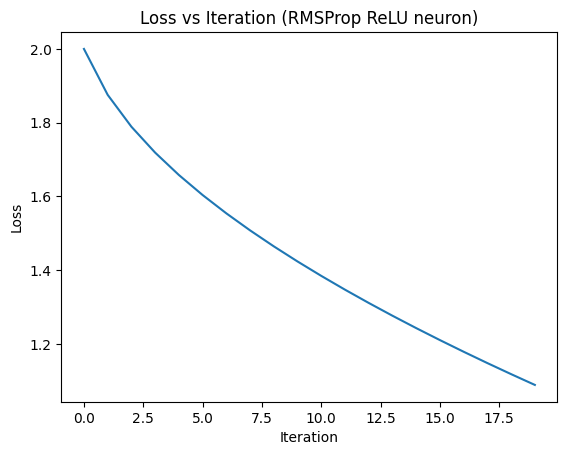

In [13]:
'''
10. Coding: RMSProp with ReLU Activation

'''

import numpy as np
import matplotlib.pyplot as plt


w = 1.5

x = 2
y = 1

lr = 0.01
beta = 0.9
eps = 1e-8

v = 0

losses = []

for t in range(20):

    z = w*x

    a = max(0,z)

    loss = 0.5*(a-y)**2

    losses.append(loss)

    if z > 0:
        relu_grad = 1
    else:
        relu_grad = 0

    g = (a-y)*relu_grad*x

    v = beta*v + (1-beta)*(g**2)

    w = w - lr*g/(np.sqrt(v)+eps)

    print("Iter:",t,
          "w:",w,
          "loss:",loss)

plt.plot(losses)

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.title("Loss vs Iteration (RMSProp ReLU neuron)")

plt.show()

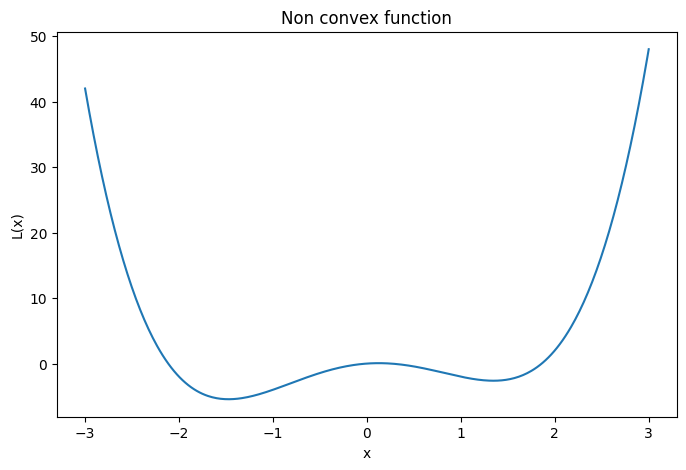

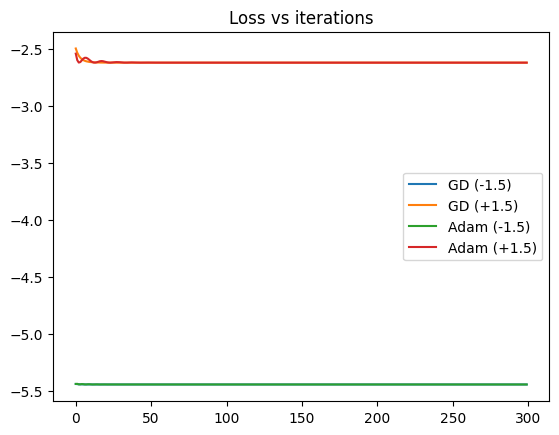

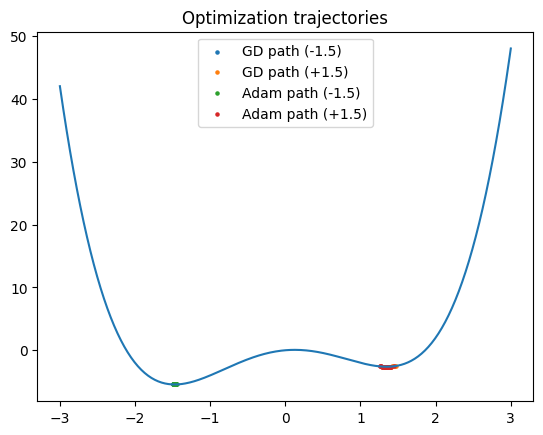

GD from -1.5: -1.4729976011140307 -5.444192066610897
GD from +1.5: 1.3469974085277747 -2.618555980765247
Adam from -1.5: -1.4729975964711746 -5.444192066610897
Adam from +1.5: 1.3469973971195484 -2.6185559807652465


In [14]:
'''

12.Coding: Optimization in a Non-Convex Loss
Consider the non-convex function
L(x) = x
4 − 4x
2 + x.
1. Plot L(x) for x ∈ [−3, 3] and identify the number of local minima.
'''

import numpy as np
import matplotlib.pyplot as plt

def L(x):

    return x**4 - 4*x**2 + x

def grad(x):

    return 4*x**3 - 8*x + 1

def gradient_descent(x0,lr=0.01,iters=300):

    x = x0

    xs=[]
    losses=[]

    for i in range(iters):

        g = grad(x)

        x = x - lr*g

        xs.append(x)
        losses.append(L(x))

    return xs,losses

def adam(x0,lr=0.05,beta1=0.9,beta2=0.999,eps=1e-8,iters=300):

    x=x0

    m=0
    v=0

    xs=[]
    losses=[]

    for t in range(1,iters+1):

        g = grad(x)

        m = beta1*m+(1-beta1)*g
        v = beta2*v+(1-beta2)*g**2

        mhat = m/(1-beta1**t)
        vhat = v/(1-beta2**t)

        x = x - lr*mhat/(np.sqrt(vhat)+eps)

        xs.append(x)
        losses.append(L(x))

    return xs,losses

x_vals=np.linspace(-3,3,400)

plt.figure(figsize=(8,5))

plt.plot(x_vals,L(x_vals))

plt.title("Non convex function")

plt.xlabel("x")
plt.ylabel("L(x)")

plt.show()

gd_neg_x,gd_neg_loss = gradient_descent(-1.5)
gd_pos_x,gd_pos_loss = gradient_descent(1.5)

adam_neg_x,adam_neg_loss = adam(-1.5)
adam_pos_x,adam_pos_loss = adam(1.5)

plt.plot(gd_neg_loss,label="GD (-1.5)")
plt.plot(gd_pos_loss,label="GD (+1.5)")

plt.plot(adam_neg_loss,label="Adam (-1.5)")
plt.plot(adam_pos_loss,label="Adam (+1.5)")

plt.legend()

plt.title("Loss vs iterations")

plt.show()

plt.plot(x_vals,L(x_vals))

plt.scatter(gd_neg_x,L(np.array(gd_neg_x)),s=5,label="GD path (-1.5)")
plt.scatter(gd_pos_x,L(np.array(gd_pos_x)),s=5,label="GD path (+1.5)")

plt.scatter(adam_neg_x,L(np.array(adam_neg_x)),s=5,label="Adam path (-1.5)")
plt.scatter(adam_pos_x,L(np.array(adam_pos_x)),s=5,label="Adam path (+1.5)")

plt.legend()

plt.title("Optimization trajectories")

plt.show()

#################################################
# Final values
#################################################

print("GD from -1.5:",gd_neg_x[-1],gd_neg_loss[-1])
print("GD from +1.5:",gd_pos_x[-1],gd_pos_loss[-1])

print("Adam from -1.5:",adam_neg_x[-1],adam_neg_loss[-1])
print("Adam from +1.5:",adam_pos_x[-1],adam_pos_loss[-1])



In [ ]:
'''

observation:
Q. Why different initializations converge to different minima?
Because the function is non-convex and has multiple local minima.
Gradient-based optimizers move toward the nearest minimum based
on the starting point.

Q. Why fixing random seeds is important for reproducibility?
Fixing random seeds ensures the same initialization and
 random operations, so the results remain consistent across multiple runs.

Q. Why trying multiple seeds helps discover better minima?
Different seeds give different starting points.
Some starting points may lead to better minima,
so trying multiple seeds increases the chance of finding a better solution.
'''

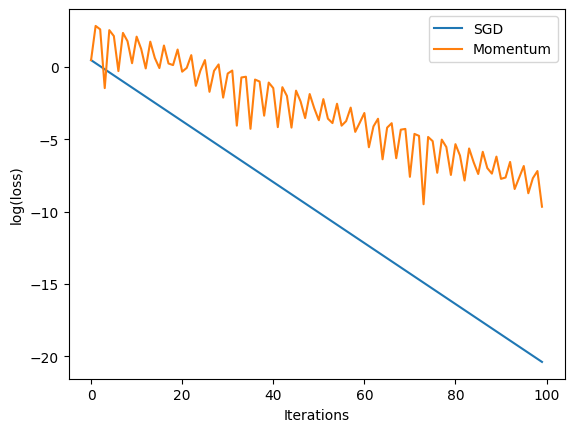

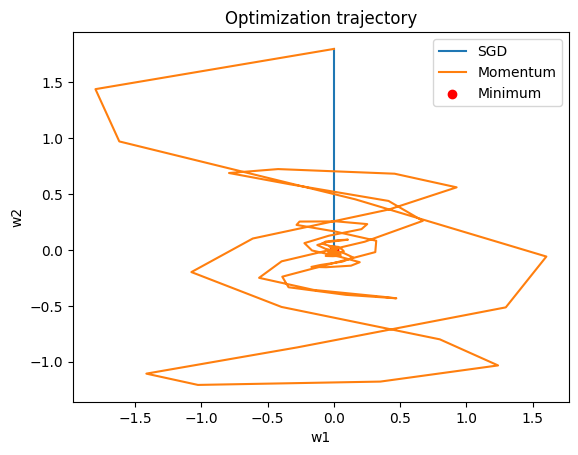

SGD final: [0.00000000e+00 5.31227978e-05] loss: 1.4110158217310646e-09
Momentum final: [0.00270009 0.00747747] loss: 6.440874502832226e-05


In [15]:
'''
14. Programming : Comparing SGD and Momentum
'''

import numpy as np
import matplotlib.pyplot as plt

def f(w):

    w1,w2=w

    return 0.5*(10*w1**2 + w2**2)

def grad(w):

    w1,w2=w

    return np.array([10*w1 , w2])


def SGD(w0,lr=0.1,iters=100):

    w=w0.copy()

    losses=[]
    traj=[]

    for i in range(iters):

        g=grad(w)

        w = w - lr*g

        losses.append(f(w))

        traj.append(w.copy())

    return w,losses,traj

def momentum(w0,lr=0.1,beta=0.9,iters=100):

    w=w0.copy()

    v=np.zeros(2)

    losses=[]
    traj=[]

    for i in range(iters):

        g=grad(w)

        v = beta*v + g

        w = w - lr*v

        losses.append(f(w))

        traj.append(w.copy())

    return w,losses,traj



w0=np.array([2.0,2.0])

w_sgd,loss_sgd,traj_sgd = SGD(w0)

w_mom,loss_mom,traj_mom = momentum(w0)

plt.plot(np.log(loss_sgd),label="SGD")

plt.plot(np.log(loss_mom),label="Momentum")

plt.xlabel("Iterations")

plt.ylabel("log(loss)")

plt.legend()

plt.show()

traj_sgd=np.array(traj_sgd)

traj_mom=np.array(traj_mom)

plt.plot(traj_sgd[:,0],traj_sgd[:,1],label="SGD")

plt.plot(traj_mom[:,0],traj_mom[:,1],label="Momentum")

plt.scatter(0,0,color='red',label="Minimum")

plt.xlabel("w1")

plt.ylabel("w2")

plt.legend()

plt.title("Optimization trajectory")

plt.show()

print("SGD final:",w_sgd,"loss:",loss_sgd[-1])

print("Momentum final:",w_mom,"loss:",loss_mom[-1])

In [ ]:
'''
observation:
Momentum accelerates optimization along directions with small curvature
(small Hessian eigenvalues) by accumulating gradients across iterations.
At the same time, it reduces oscillations along directions with
large curvature (large eigenvalues). This leads to faster convergence
compared to vanilla SGD, which treats each direction independently
 without using past gradient information.
'''

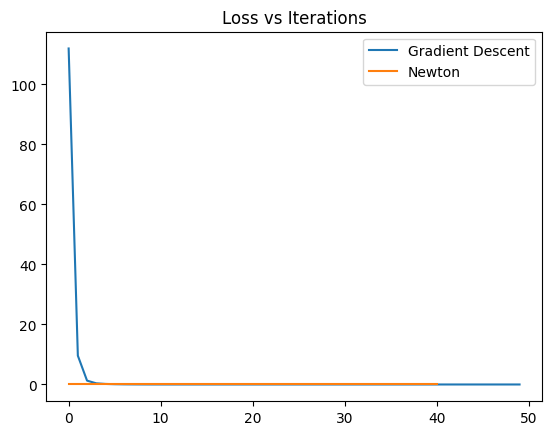

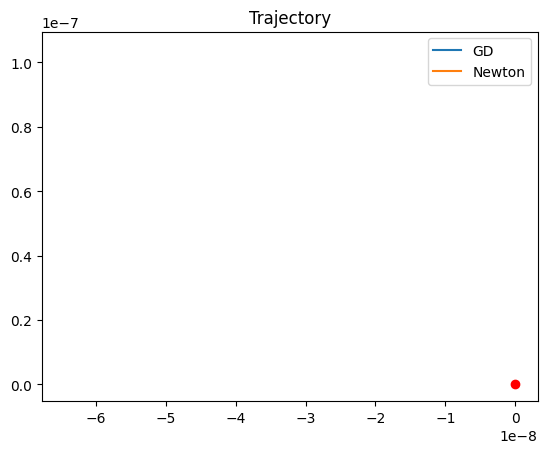

GD final: [-6.4525523e-08  1.0440448e-07] loss: 3.9758286588106526e-14
Newton final: [0. 0.] loss: 0.0


In [19]:
'''
15.Programming: Gradient Descent vs Newton’s Method

'''
import torch
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    return 3*w[0]**2 + 2*w[0]*w[1] + 2*w[1]**2

w = torch.tensor([4.0,4.0],requires_grad=True)

lr=0.1

loss_gd=[]
traj_gd=[]

for i in range(50):

    loss=f(w)

    loss.backward()

    with torch.no_grad():

        w -= lr*w.grad

    w.grad.zero_()

    loss_gd.append(loss.item())

    traj_gd.append(w.detach().numpy())

w = torch.tensor([4.0,4.0])

H=torch.tensor([[6.0,2.0],
                [2.0,4.0]])

Hinv=torch.inverse(H)

loss_newton=[]
traj_newton=[]

for i in range(5):

    g=torch.tensor([6*w[0]+2*w[1],
                    2*w[0]+4*w[1]])

    w = w - Hinv@g

    loss_newton.append(f(w).item())

    traj_newton.append(w.numpy())

plt.plot(loss_gd,label="Gradient Descent")

plt.plot(range(0,50,10),
         loss_newton,
         label="Newton")

plt.legend()

plt.title("Loss vs Iterations")

plt.show()

traj_gd = np.array(traj_gd)
traj_newton = np.array(traj_newton)

plt.plot(traj_gd[:,0],traj_gd[:,1],label="GD")

plt.plot(traj_newton[:,0],
         traj_newton[:,1],
         label="Newton")

plt.scatter(0,0,color='red')

plt.legend()

plt.title("Trajectory")

plt.show()

print("GD final:",traj_gd[-1],"loss:",loss_gd[-1])

print("Newton final:",traj_newton[-1],"loss:",loss_newton[-1])


In [ ]:
'''
Observation:
Gradient Descent converges slowly because it only uses gradient information.
Newton’s method converges faster because it uses curvature (Hessian) information
and directly moves toward the minimum. For quadratic functions,
Newton’s method can converge in one iteration.
'''